In [5]:
from graphviz import Digraph
import random
import math
from typing import Callable
import torch

In [82]:
class Expression:
    def __init__(self, value: float = 0.0):
        self.value = value
        self.grad = 0.0
        self.operands = []
        self.op = ''
        self.backward = lambda: None
        self.forward = lambda: None
        self.tensor = torch.Tensor([value]).double()
        self.tensor.requires_grad = True

    def unary(self, op: str, backward: Callable[[], None], forward: Callable[[], None], operand):
        self.op = op
        self.backward = backward        
        self.forward = forward
        self.forward()
        self.operands = [operand]        

    def binary(self, op: str, backward: Callable[[], None], forward: Callable[[], None], operand0, operand1):
        self.op = op
        self.backward = backward        
        self.forward = forward
        self.forward()
        self.operands = [operand0, operand1]        

    def __add__(self, other):
        result = Expression()                
        def backward():
            self.grad += result.grad
            other.grad += result.grad                                
        def forward():
            self.forward()
            other.forward()
            result.value = self.value + other.value   
            result.tensor = self.tensor + other.tensor
            result.tensor.retain_grad();
        result.binary(
            '+',
            backward,
            forward,
            self,
            other
        )
        return result

    def __mul__(self, other):
        result = Expression()        
        def backward():
            self.grad += other.value * result.grad
            other.grad += self.value * result.grad                    
        def forward():
            self.forward()
            other.forward()
            result.value = self.value * other.value        
            result.tensor = self.tensor * other.tensor
            result.tensor.retain_grad();
        result.binary(
            '*',
            backward,
            forward,
            self,
            other
        )
        return result

    def __truediv__(self, other):
        result = Expression()        
        def backward():
            self.grad += (1.0 / other.value) * result.grad
            other.grad += (-self.value / (other.value * other.value)) * result.grad                    
        def forward():
            self.forward()
            other.forward()
            result.value = self.value / other.value
            result.tensor = self.tensor / other.tensor
            result.tensor.retain_grad();
        result.binary(
            '/',
            backward,
            forward,
            self,
            other
        )
        return result

    def __pow__(self, other):
        result = Expression()        
        def backward():
            self.grad += other.value * math.pow(self.value, other.value - 1) * result.grad
            other.grad += math.pow(self.value, other.value) * math.log(self.value) * result.grad                    
        def forward():
            self.forward()
            other.forward()
            result.value = math.pow(self.value, other.value)  
            result.tensor = torch.Tensor.pow(self.tensor, other.tensor);
            result.tensor.retain_grad();
        result.binary(
            '**',
            backward,
            forward,
            self,
            other
        )
        return result

    def exp(self):
        result = Expression()        
        def backward():
            self.grad += math.exp(self.value) * result.grad            
        result.backward = backward
        def forward():
            self.forward()            
            result.value = math.exp(self.value)   
            result.tensor = torch.Tensor.exp(self.tensor);
            result.tensor.retain_grad();     
        result.unary(
            'exp',
            backward,
            forward,
            self,            
        )
        return result

    def tanh(self):
        result = Expression()        
        def backward():
            self.grad += (1.0 - math.pow(math.tanh(self.value), 2)) * result.grad        
        def forward():
            self.forward()            
            result.value = math.tanh(self.value)   
            result.tensor = torch.Tensor.tanh(self.tensor);
            result.tensor.retain_grad();          
        result.unary(
            'exp',
            backward,
            forward,
            self,            
        )
        return result


def collect_tsorted(root : Expression):
    result = []
    def tsort(e: Expression):
        if e not in result:
            result.append(e)
            for o in e.operands:
                tsort(o)
    tsort(root)
    return result    

def backward(root : Expression):
    result = collect_tsorted(root)
    for e in result:
        e.grad = 0.0
    root.grad = 1
    for e in result:
        e.backward()
    result[0].tensor.backward()

def test_grad_by_estimation(root: Expression):
    result = collect_tsorted(root)
    noops = [e for e in result if not e.op]    
    original_values = [e.value for e in noops]
    backward(root)
    original_result = root.value    
    original_grads = [e.grad for e in noops]
    estimated_grads = []    
    epsilon = 0.00001
    for i in range(len(noops)):        
        noops[i].value = original_values[i] + epsilon
        root.forward()        
        estimated_grads.append((root.value - original_result) / epsilon)
        noops[i].value = original_values[i]
    torch_grads = []
    for i in range(len(noops)):            
        torch_grads.append(noops[i].tensor.grad.item())
    print("original", original_grads)
    print("estimated", estimated_grads)
    print("torch", torch_grads)

# orphan nodes are not matter
def create_random_graph(depth: int):
    nodes = [Expression(random.randint(1, 3)) for i in range(depth)]
    depth -= 1
    while depth > 0:
        level = []
        for i in range(depth):
            kind = random.randint(1, 6)
            random.shuffle(nodes)
            x = nodes[0]
            y = nodes[1]
            if kind == 1:
                level.append(x + y)                
            elif kind == 2:
                level.append(x * y)                                
            elif kind == 3:
                level.append(x / y)                                
            elif kind == 4:
                level.append(x ** y)
            elif kind == 5:
                level.append(x.exp())                
            elif kind == 6:
                level.append(x.tanh())
        nodes.extend(level)
        depth -= 1
    return nodes[-1]    

def create_random_tree(depth: int):
    if depth < 2:
        return Expression(random.randint(1, 5))
    # add, mul, div, pow, exp, tanh
    kind = random.randint(1, 6)
    depth = depth - 1
    if kind == 1:
        return create_random_tree(depth) + create_random_tree(depth)
    elif kind == 2:
        return create_random_tree(depth) * create_random_tree(depth)
    elif kind == 3:
        return create_random_tree(depth) / create_random_tree(depth)
    elif kind == 4:
        return create_random_tree(depth) ** create_random_tree(depth)
    elif kind == 5:
        return create_random_tree(depth).exp()
    elif kind == 6:
        return create_random_tree(depth).tanh()

    

In [83]:
def trace(e: Expression):
    nodes, edges = set(), set()
    def build(v: Expression):
        if v not in nodes:
            nodes.add(v)
            for o in v.operands:
                edges.add((o, v))
                build(o)
    build(e)
    return nodes, edges

def draw_dot(root: Expression, format='svg', rankdir = 'LR'):
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    for n in nodes:
        dot.node(name=str(id(n)), label="{value %.4f | grad %.4f}" % (n.value, n.grad), shape='record')
        if n.op:
            dot.node(name=str(id(n)) + n.op, label=n.op)
            dot.edge(str(id(n)) + n.op, str(id(n)))
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)
    return dot

original [0.009866037165440211]
estimated [0.009865938987996259]
torch [0.009866037165440211]


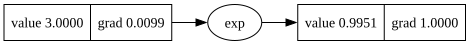

In [112]:
d = create_random_graph(3)

test_grad_by_estimation(d)

backward(d)
draw_dot(d)


In [12]:
v1 = torch.Tensor([3]).double()
v2 = torch.Tensor([3]).double()
v3 = torch.Tensor([1]).double()
v4 = torch.Tensor([1]).double()

v1.requires_grad = True;
v2.requires_grad = True;
v3.requires_grad = True;
v4.requires_grad = True;

w1 = v1 * v2
w2 = v3 + v4

w1.retain_grad();
w2.retain_grad();

z1 = w1 + w2;

z1.backward()
print(v1.grad.item(), v2.grad.item(), v3.grad.item(), v4.grad.item())
print(w1.grad.item(), w2.grad.item())






3.0 3.0 1.0 1.0
1.0 1.0
